In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
alpha = 0.015
total_steps = 250

A = np.diag(np.array([1, 100]))

In [3]:
def loss_function(theta):
    return (0.5)*theta.T@A@theta

def grad_function(theta):
    return A@theta

def norm_grad_function(grad):
    return np.linalg.norm(grad)

def theta_update(theta):
    new_update = alpha*grad_function(theta)
    new_theta = theta - new_update
    return new_theta, new_update

def sgd_grad_function(theta, k):
    grad_mean = 0
    grad_std = 1
    total_noise_epsilon = 0
    for _ in range(k):
        total_noise_epsilon = total_noise_epsilon + np.random.normal(grad_mean, grad_std, 2)
    noise_epsilon =  total_noise_epsilon/k
    noisy_grad = A@theta + noise_epsilon
    return noisy_grad

def sgd_norm_grad_function(grad):
    return np.linalg.norm(grad)

def sgd_theta_update(theta, k):
    new_update = alpha*sgd_grad_function(theta, k)
    new_theta = theta - new_update
    return new_theta, new_update

In [4]:
def sgd_optimization(theta0, k):
    # Stochastic Gradient Descent
    sgd_theta_hist = []
    sgd_loss_hist = []
    sgd_update_norm_hist = []
    
    curr_sgd_theta = theta0
    curr_sgd_loss = loss_function(curr_sgd_theta)
    
    sgd_theta_hist.append(curr_sgd_theta)
    sgd_loss_hist.append(curr_sgd_loss)
    
    for _ in range(total_steps):    
        curr_sgd_theta, curr_sgd_new_update = sgd_theta_update(curr_sgd_theta, k)
        curr_sgd_loss = loss_function(curr_sgd_theta)
        curr_update_norm = sgd_norm_grad_function(curr_sgd_new_update)
        
        sgd_theta_hist.append(curr_sgd_theta)
        sgd_loss_hist.append(curr_sgd_loss)
        sgd_update_norm_hist.append(curr_update_norm)

    return {
        "sgd_theta_hist": sgd_theta_hist,
        "sgd_loss_hist": sgd_loss_hist,
        "sgd_update_norm_hist": sgd_update_norm_hist
    }

In [5]:
theta0 = np.array([5, 5])
theta_star = np.array([0.0, 0.0])

In [6]:
# Gradient Descent
theta_hist = []
loss_hist = []
grad_norm_hist = []

curr_theta = theta0
curr_loss = loss_function(curr_theta)

theta_hist.append(curr_theta)
loss_hist.append(curr_loss)

for _ in range(total_steps):    
    curr_theta, curr_new_update = theta_update(curr_theta)
    curr_loss = loss_function(curr_theta)
    curr_grad_norm = norm_grad_function(curr_new_update)
    
    theta_hist.append(curr_theta)
    loss_hist.append(curr_loss)
    grad_norm_hist.append(curr_grad_norm)


In [7]:
x_linspace = np.linspace(-6, 6, 1500)
y_linspace = np.linspace(-6, 6, 1500)
X, Y = np.meshgrid(x_linspace, y_linspace)

Z = 0.5*(X**2 + 100*Y**2)

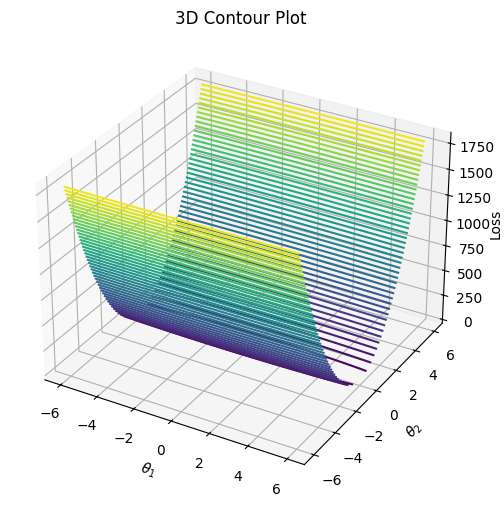

In [8]:
# 3D contour plot
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.contour3D(X, Y, Z, 50)

ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.set_zlabel('Loss', rotation=90, labelpad=1)
ax.set_title('3D Contour Plot')

plt.show()

In [9]:
def plot_graph(theta0, theta_star, custom_theta_hist, custom_loss_hist, custom_grad_norm_hist):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Parameter space with loss function
    ax = axes[0]
    ax.plot(np.array(custom_theta_hist)[:,0], np.array(custom_theta_hist)[:,1], markersize=1, label="θ path")
    ax.scatter([theta0[0]], [theta0[1]], color="red", label="init θ")
    ax.scatter([theta_star[0]], [theta_star[1]], color="green", label="minimum θ*")
    ax.legend()
    
    cf = ax.contour(X, Y, Z, levels=30)
    fig.colorbar(cf, ax=ax, label="Loss value")
    
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    ax.set_title('Optimization')

    # Loss over step
    ax = axes[1]
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.plot(np.arange(len(custom_loss_hist)), np.array(custom_loss_hist), markersize=1)
    ax.set_title('Loss vs Step')
    ax.set_yscale('log')

    # Grad norm over step
    ax = axes[2]
    ax.set_xlabel('Step')
    ax.set_ylabel('Update norm')
    ax.plot(np.arange(len(custom_grad_norm_hist)), np.array(custom_grad_norm_hist), markersize=1)
    ax.set_title('Update norm vs Step')
    ax.set_yscale('log')
    

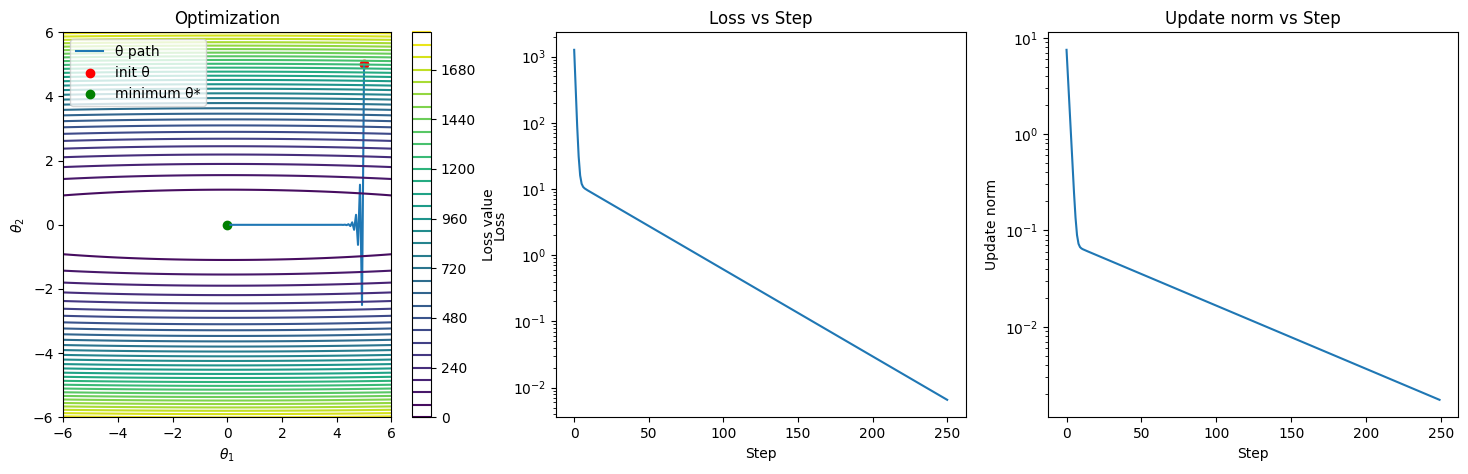

In [10]:
plot_graph(theta0, theta_star, theta_hist, loss_hist, grad_norm_hist)

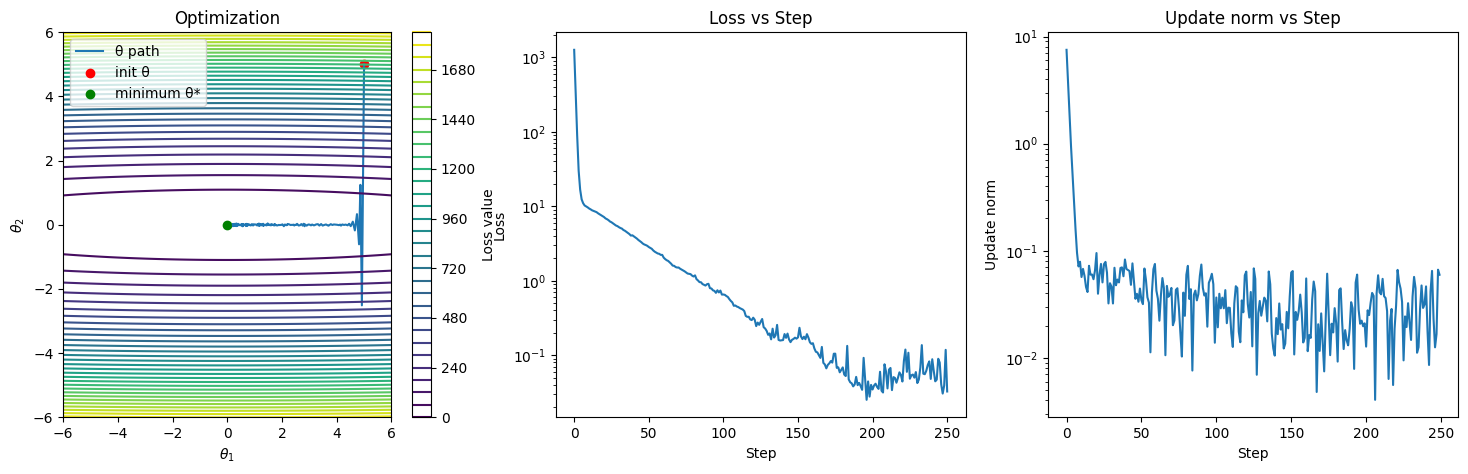

In [11]:
# Mini-batch, k = 1 
k = 1
sgd_optimization_result = sgd_optimization(theta0, k)
sgd_theta_hist = sgd_optimization_result["sgd_theta_hist"]
sgd_loss_hist = sgd_optimization_result["sgd_loss_hist"]
sgd_update_norm_hist =  sgd_optimization_result["sgd_update_norm_hist"]

plot_graph(theta0, theta_star, sgd_theta_hist, sgd_loss_hist, sgd_update_norm_hist)

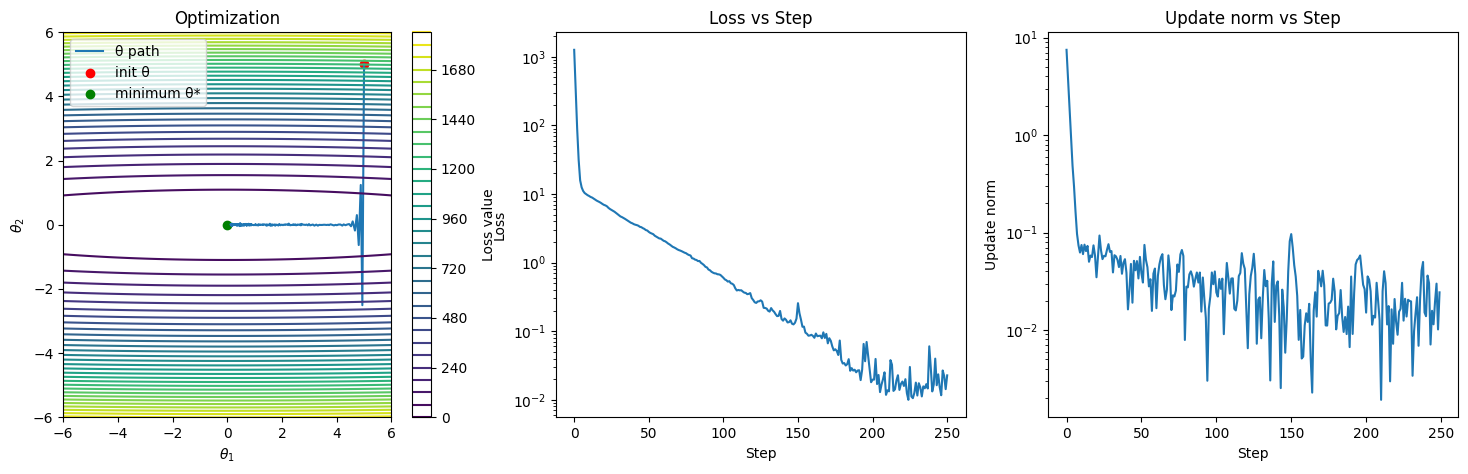

In [12]:
# Mini-batch, k = 2 
k = 2
sgd_optimization_result = sgd_optimization(theta0, k)
sgd_theta_hist = sgd_optimization_result["sgd_theta_hist"]
sgd_loss_hist = sgd_optimization_result["sgd_loss_hist"]
sgd_update_norm_hist =  sgd_optimization_result["sgd_update_norm_hist"]

plot_graph(theta0, theta_star, sgd_theta_hist, sgd_loss_hist, sgd_update_norm_hist)

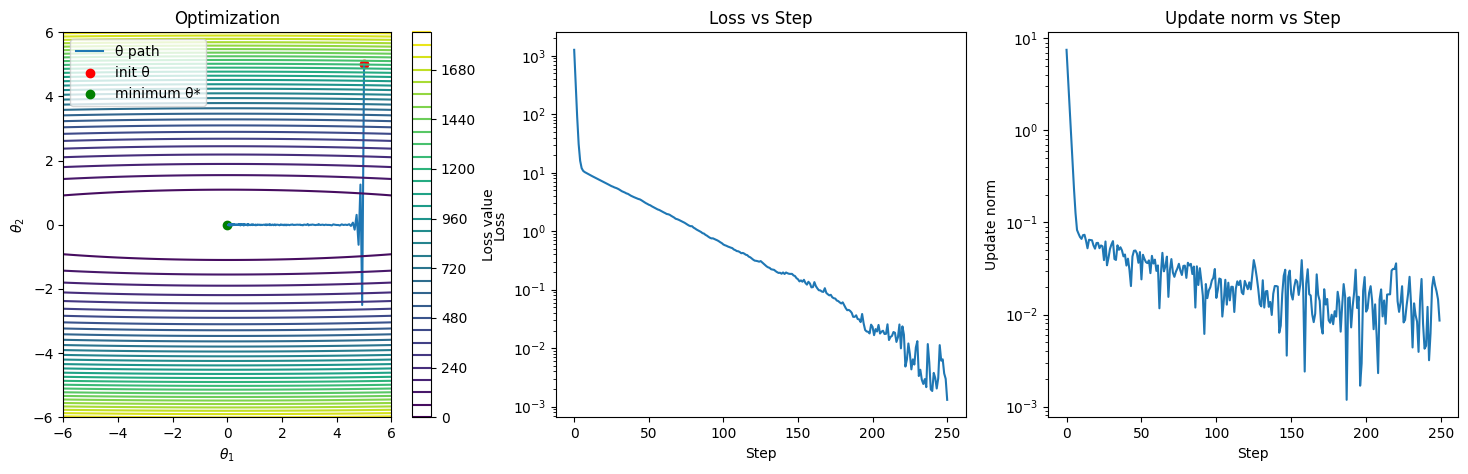

In [13]:
# Mini-batch, k = 4
k = 4
sgd_optimization_result = sgd_optimization(theta0, k)
sgd_theta_hist = sgd_optimization_result["sgd_theta_hist"]
sgd_loss_hist = sgd_optimization_result["sgd_loss_hist"]
sgd_update_norm_hist =  sgd_optimization_result["sgd_update_norm_hist"]

plot_graph(theta0, theta_star, sgd_theta_hist, sgd_loss_hist, sgd_update_norm_hist)

In [ ]:
# Mini-batch, k = 8
k = 8
sgd_optimization_result = sgd_optimization(theta0, k)
sgd_theta_hist = sgd_optimization_result["sgd_theta_hist"]
sgd_loss_hist = sgd_optimization_result["sgd_loss_hist"]
sgd_update_norm_hist =  sgd_optimization_result["sgd_update_norm_hist"]

plot_graph(theta0, theta_star, sgd_theta_hist, sgd_loss_hist, sgd_update_norm_hist)

In [ ]:
# Mini-batch, k = 16
k = 16
sgd_optimization_result = sgd_optimization(theta0, k)
sgd_theta_hist = sgd_optimization_result["sgd_theta_hist"]
sgd_loss_hist = sgd_optimization_result["sgd_loss_hist"]
sgd_update_norm_hist =  sgd_optimization_result["sgd_update_norm_hist"]

plot_graph(theta0, theta_star, sgd_theta_hist, sgd_loss_hist, sgd_update_norm_hist)

In [ ]:
# Mini-batch, k = 32
k = 32
sgd_optimization_result = sgd_optimization(theta0, k)
sgd_theta_hist = sgd_optimization_result["sgd_theta_hist"]
sgd_loss_hist = sgd_optimization_result["sgd_loss_hist"]
sgd_update_norm_hist =  sgd_optimization_result["sgd_update_norm_hist"]

plot_graph(theta0, theta_star, sgd_theta_hist, sgd_loss_hist, sgd_update_norm_hist)

In [ ]:
# Mini-batch, k = 64
k = 64
sgd_optimization_result = sgd_optimization(theta0, k)
sgd_theta_hist = sgd_optimization_result["sgd_theta_hist"]
sgd_loss_hist = sgd_optimization_result["sgd_loss_hist"]
sgd_update_norm_hist =  sgd_optimization_result["sgd_update_norm_hist"]

plot_graph(theta0, theta_star, sgd_theta_hist, sgd_loss_hist, sgd_update_norm_hist)